# Download and mask ERA5 drought data for Africa

This notebook downloads monthly ERA5 drought data from the Copernicus Climate Data Store using `cdsapi`, extracts the NetCDF file, applies a precise Africa mask using `c3s_atlas.mask_africa`, previews the result, and saves the final masked NetCDF.

Before running it, make sure your CDS credentials are configured in `~/.cdsapirc`.

In [1]:
from importlib import reload
from pathlib import Path

import cdsapi
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import regionmask
from shapely.ops import unary_union

import c3s_atlas.customized_regions as cr
from c3s_atlas.utils import extract_zip_and_delete


/home/abdessamadelh/miniconda3/envs/atlas-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Resolve project paths

This makes the notebook work whether Jupyter was started from the repository root or from a subdirectory.

In [2]:
repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "c3s_atlas").exists() and (path / "auxiliar").exists()
)

dest = repo_root / "book" / "customizing" / "data" / "africa_era5_drought"
dest.mkdir(parents=True, exist_ok=True)

repo_root, dest


(PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main'),
 PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_drought'))

## Download ERA5 from CDS

The request uses the `multi-origin-c3s-atlas` dataset already used in this repository. The geographical subset is a broad Africa bounding box, and the precise continent mask is applied afterward. This version switches to a drought indicator (SPEI-6) and uses a slightly more detailed Natural Earth boundary layer for a cleaner continental mask.

In [3]:
c = cdsapi.Client()

request_variable = "monthly_standardised_precipitation_evapotranspiration_index_for_6_months_cumulation_period"

# This drought setup uses the SPEI-6 variable already referenced elsewhere
# in this repository for Copernicus Atlas downloads.
zip_path = dest / "spei6_ERA5_Africa.zip"
dataset = "multi-origin-c3s-atlas"
request = {
    "origin": "era5",
    "domain": "global",
    "period": "1940-2024",
    "variable": request_variable,
    "bias_adjustment": "no_bias_adjustment",
    "area": [38, -20, -36, 55],
}

if not list(dest.glob("*.nc")):
    c.retrieve(dataset, request).download(zip_path)
    extract_zip_and_delete(zip_path)
    print("Download and extraction complete.")
else:
    print(f"NetCDF already present in {dest}")


2026-04-06 02:04:19,066 INFO [2025-09-24T09:00:00] Help shape the future of the C3S Atlas by letting us know how you use it (including the application, this dataset, the documentation and user tools), and whether there are any additions or improvements you would like to see in the future. Complete the [C3S Atlas User Survey](https://ec.europa.eu/eusurvey/runner/791fd0a8-6c85-0971-4360-b98b2c585843).
2026-04-06 02:04:19,075 INFO Request ID is 697ff58d-88d7-4840-a304-f03a68acb44d
2026-04-06 02:04:19,674 INFO status has been updated to accepted
2026-04-06 02:04:41,665 INFO status has been updated to running
2026-04-06 02:05:10,915 INFO status has been updated to successful


provenance.json
provenance.png
spei6_ERA5_no-expt_mon_19400101-20241201.nc
Download and extraction complete.


## Open the downloaded NetCDF

In [4]:
nc_files = sorted(
    path for path in dest.glob("*.nc")
    if path.name != "era5_africa_drought_masked.nc"
)
if not nc_files:
    raise FileNotFoundError(f"No NetCDF file found in {dest}")

nc_path = nc_files[0]
ds = xr.open_dataset(nc_path)

print("Opened:", nc_path.name)
print("Dimensions:", ds.dims)
print("Data variables:", list(ds.data_vars))
ds


Opened: spei6_ERA5_Africa.nc
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 297, 'bnds': 2, 'lon': 301, 'time': 1020})
Data variables: ['lat_bnds', 'lon_bnds', 'time_bnds', 'spei6', 'crs']


<xarray.Dataset> Size: 365MB
Dimensions:    (lat: 297, bnds: 2, lon: 301, time: 1020)
Coordinates:
  * lat        (lat) float64 2kB -36.0 -35.75 -35.5 -35.25 ... 37.5 37.75 38.0
  * lon        (lon) float64 2kB -20.0 -19.75 -19.5 -19.25 ... 54.5 54.75 55.0
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) float64 5kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    time_bnds  (time, bnds) datetime64[ns] 16kB ...
    spei6      (time, lat, lon) float32 365MB ...
    crs        int32 4B ...
Attributes: (12/26)
    Conventions:                CF-1.9 ACDD-1.3
    title:                      Copernicus Interactive Climate Atlas: gridded...
    summary:                    Monthly/annual gridded data from observations...
    institution:                Copernicus Climate Change Service (C3S)
    producers:                  Institute of Physics of Cantabria (IFCA, CSIC...
    license:                    CC-BY 4.0, https://creativecommons.org/licens...
    ...                         ...
    geospatial_lon_max:         179.875
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east
    date_created:               2025-03-31 17:20:58.422650+02:00
    tracking_id:                214fe8d1-e29d-48fd-afaf-e7260d2d3c80
    project_id:                 c3s-cica-atlas

## Build a precise Africa mask from a finer Natural Earth layer and apply it

This avoids the incomplete local Africa GeoJSON and uses a finer-resolution Natural Earth country boundary layer directly.

In [5]:
reload(cr)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
)
africa_gdf = world[world["CONTINENT"] == "Africa"].copy()

# Fix possible geometry issues before dissolving into one continent polygon.
africa_gdf["geometry"] = africa_gdf.geometry.buffer(0)
africa_shape = unary_union(africa_gdf.geometry)

africa_region = regionmask.Regions(
    [africa_shape],
    names=["Africa"],
    abbrevs=["AFR"],
    name="Africa continent",
)

mask = africa_region.mask(ds["lon"], ds["lat"])
ds_africa = ds.where(mask == 0)
ds_africa = cr.crop_to_bbox(ds_africa, lon_bounds=(-18.0, 52.0), lat_bounds=(-35.0, 37.5))

print("African entities used:", len(africa_gdf))
print("Sample names:", africa_gdf["NAME"].head().tolist())
print("Masked dimensions:", ds_africa.dims)
print("Masked variables:", list(ds_africa.data_vars))
ds_africa


African entities used: 54
Sample names: ['Zimbabwe', 'Zambia', 'Uganda', 'Tunisia', 'Togo']
Masked dimensions: FrozenMappingWarningOnValuesAccess({'lat': 291, 'bnds': 2, 'lon': 281, 'time': 1020})
Masked variables: ['lat_bnds', 'lon_bnds', 'time_bnds', 'spei6', 'crs']


<xarray.Dataset> Size: 2GB
Dimensions:    (lat: 291, bnds: 2, lon: 281, time: 1020)
Coordinates:
  * lat        (lat) float64 2kB -35.0 -34.75 -34.5 -34.25 ... 37.0 37.25 37.5
  * lon        (lon) float64 2kB -18.0 -17.75 -17.5 -17.25 ... 51.5 51.75 52.0
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds, lon) float64 1MB nan nan nan nan ... nan nan nan nan
    lon_bnds   (lon, bnds, lat) float64 1MB nan nan nan nan ... nan nan nan nan
    time_bnds  (time, bnds, lat, lon) datetime64[ns] 1GB NaT NaT NaT ... NaT NaT
    spei6      (time, lat, lon) float32 334MB nan nan nan nan ... nan nan nan
    crs        (lat, lon) float64 654kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/26)
    Conventions:                CF-1.9 ACDD-1.3
    title:                      Copernicus Interactive Climate Atlas: gridded...
    summary:                    Monthly/annual gridded data from observations...
    institution:                Copernicus Climate Change Service (C3S)
    producers:                  Institute of Physics of Cantabria (IFCA, CSIC...
    license:                    CC-BY 4.0, https://creativecommons.org/licens...
    ...                         ...
    geospatial_lon_max:         179.875
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east
    date_created:               2025-03-31 17:20:58.422650+02:00
    tracking_id:                214fe8d1-e29d-48fd-afaf-e7260d2d3c80
    project_id:                 c3s-cica-atlas

## Quick preview

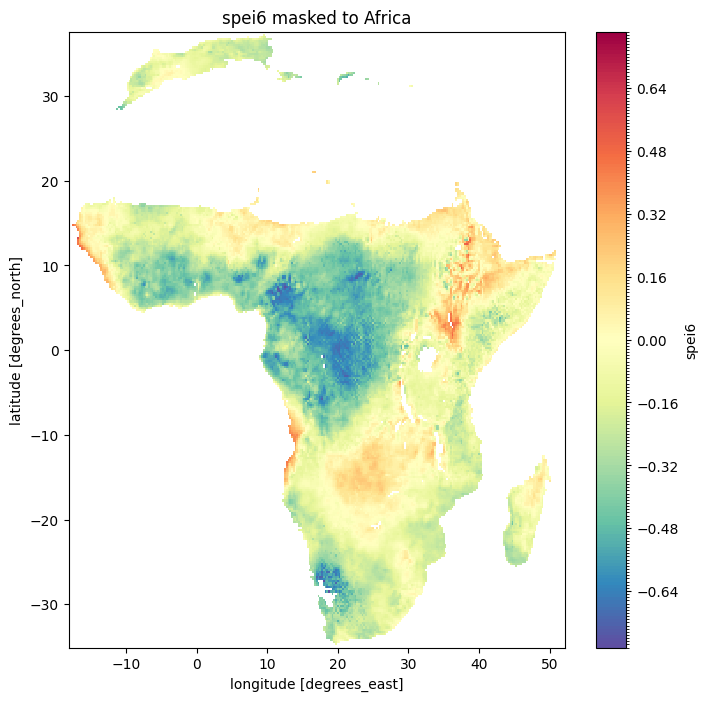

In [6]:
preferred_vars = ["spei6", "spi6", "spei", "drought", "monthly_standardised_precipitation_evapotranspiration_index_for_6_months_cumulation_period"]
var_name = next((name for name in preferred_vars if name in ds_africa.data_vars), None)

if var_name is None:
    candidates = [
        name for name, da in ds_africa.data_vars.items()
        if {"lat", "lon"}.issubset(da.dims) and "bnds" not in da.dims
    ]
    if not candidates:
        raise ValueError("No plottable data variable with lat/lon dimensions was found.")
    var_name = candidates[0]

da = ds_africa[var_name]
time_dims = [dim for dim in ("time", "valid_time") if dim in da.dims]
plot_da = da.mean(time_dims[0], skipna=True) if time_dims else da

#plot_da.plot(figsize=(8, 8), cmap="coolwarm", vmin=10, vmax=35)
plot_da.plot(figsize=(8, 8), cmap="Spectral_r", levels=255)


plt.title(f"{var_name} masked to Africa")
plt.show()


## Save the final Africa-only NetCDF

This drops auxiliary bounds variables before writing to keep the output cleaner and lighter.

In [7]:
bounds_vars = [name for name in ds_africa.variables if "bnds" in name.lower() or name.lower().endswith("_bounds")]
ds_africa_clean = ds_africa.drop_vars(bounds_vars, errors="ignore")
output_path = dest / "era5_africa_drought_masked.nc"

if output_path.exists():
    output_path.unlink()

ds.close()
 
output_path = dest / "era5_africa_drought_masked.nc"
encoding = {
    name: {"zlib": True, "complevel": 1}
    for name in ds_africa_clean.data_vars
}

ds_africa_clean.to_netcdf(output_path, encoding=encoding)
print("Saved:", output_path)


Saved: /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/africa_era5_drought/era5_africa_drought_masked.nc
